# Brazil E-Commerce — Order Items Analysis

Analysis of the **Olist `olist_order_items_dataset.csv`** file.

Columns:
- `order_id` — key to the orders dataset
- `order_item_id` — sequential item number within an order
- `product_id` — key to the products dataset
- `seller_id` — key to the sellers dataset
- `shipping_limit_date` — seller's shipping deadline
- `price` — item price (BRL)
- `freight_value` — shipping cost charged for the item (BRL)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
items = pd.read_csv(
    "Data/olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"],
)
print(f"Shape: {items.shape[0]:,} rows x {items.shape[1]} columns")
items.head()

Shape: 112,650 rows x 7 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [3]:
items.info()
items.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(items.isna().sum())

print(f"\nFully duplicated rows: {items.duplicated().sum():,}")
print(f"Distinct orders:   {items['order_id'].nunique():,}")
print(f"Distinct products: {items['product_id'].nunique():,}")
print(f"Distinct sellers:  {items['seller_id'].nunique():,}")

Missing values per column:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Fully duplicated rows: 0
Distinct orders:   98,666
Distinct products: 32,951
Distinct sellers:  3,095


## 3. Items per order

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: order_item_id, dtype: float64


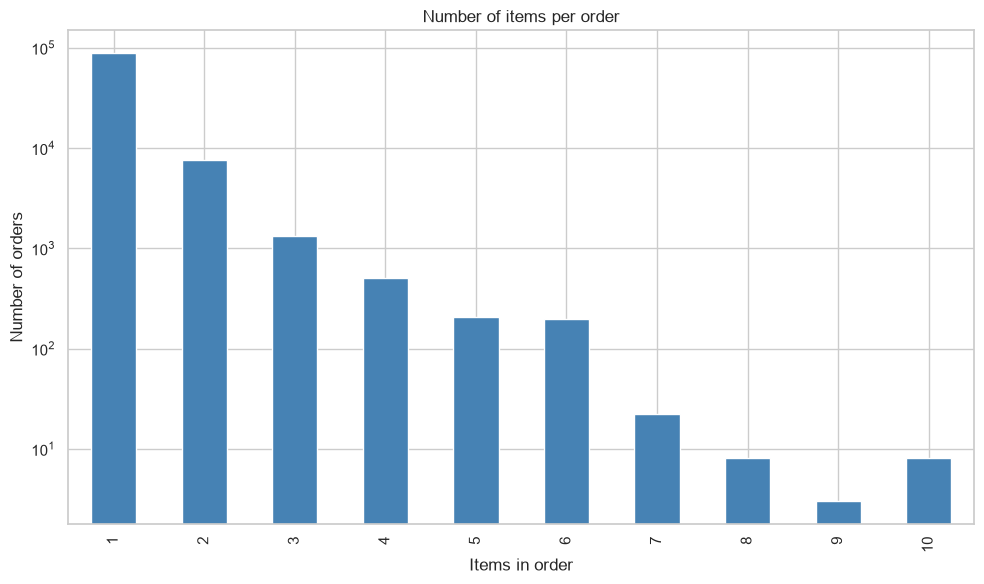

In [5]:
items_per_order = items.groupby("order_id")["order_item_id"].max()
print(items_per_order.describe())

dist = items_per_order.value_counts().sort_index()
ax = dist.head(10).plot(kind="bar", color="steelblue")
ax.set_title("Number of items per order")
ax.set_xlabel("Items in order")
ax.set_ylabel("Number of orders")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Price and freight distributions

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


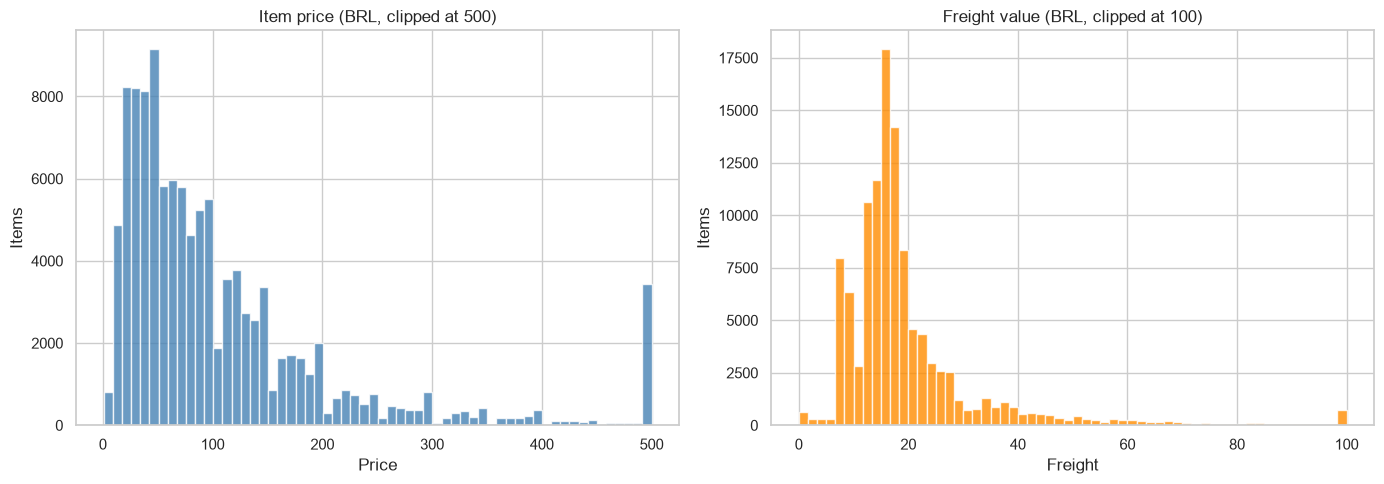

In [6]:
print(items[["price", "freight_value"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(items["price"].clip(0, 500), bins=60, color="steelblue", alpha=0.8)
axes[0].set_title("Item price (BRL, clipped at 500)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Items")

axes[1].hist(items["freight_value"].clip(0, 100), bins=60, color="darkorange", alpha=0.8)
axes[1].set_title("Freight value (BRL, clipped at 100)")
axes[1].set_xlabel("Freight")
axes[1].set_ylabel("Items")

plt.tight_layout()
plt.show()

In [7]:
items["freight_ratio"] = items["freight_value"] / items["price"].replace(0, np.nan)
print(f"Median freight as % of price: {items['freight_ratio'].median():.1%}")
print(f"Total GMV (price):    R$ {items['price'].sum():,.0f}")
print(f"Total freight:        R$ {items['freight_value'].sum():,.0f}")

Median freight as % of price: 23.1%
Total GMV (price):    R$ 13,591,644
Total freight:        R$ 2,251,910


## 5. Top sellers and products by revenue

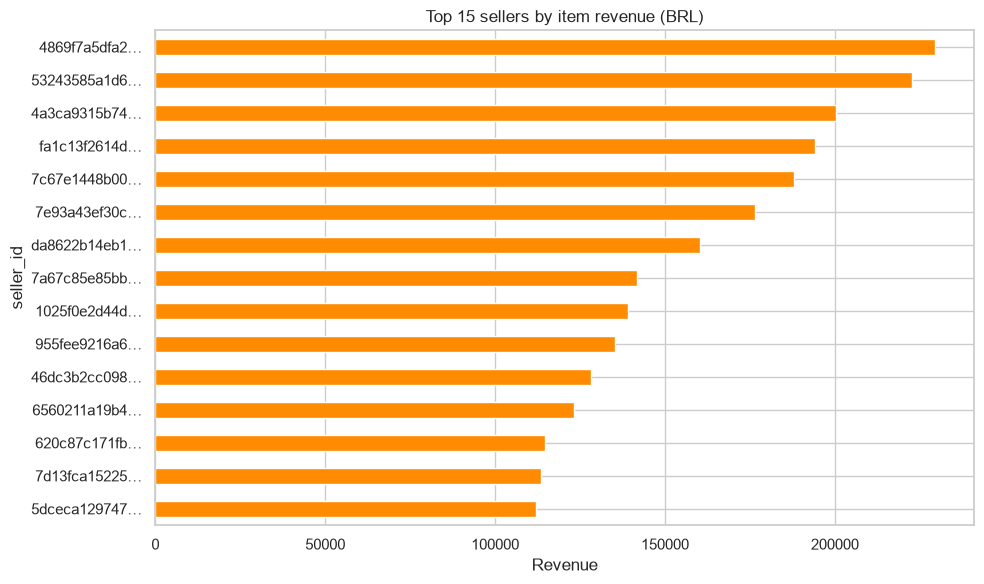

In [8]:
top_sellers = items.groupby("seller_id")["price"].sum().sort_values(ascending=False).head(15)
ax = top_sellers.plot(kind="barh", color="darkorange")
ax.invert_yaxis()
ax.set_title("Top 15 sellers by item revenue (BRL)")
ax.set_xlabel("Revenue")
ax.set_yticklabels([s[:12] + "…" for s in top_sellers.index])
plt.tight_layout()
plt.show()

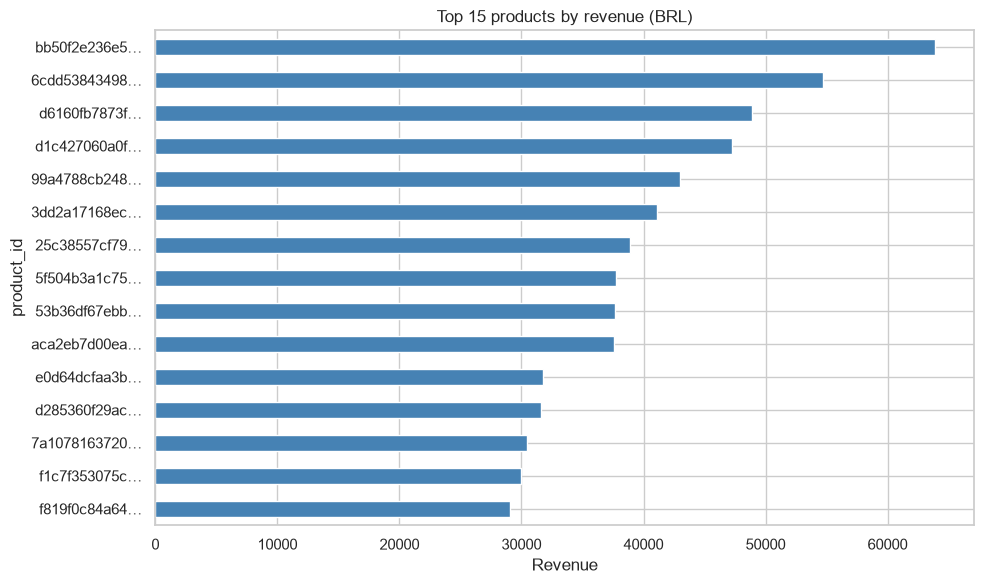

In [9]:
top_products = items.groupby("product_id")["price"].sum().sort_values(ascending=False).head(15)
ax = top_products.plot(kind="barh", color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 products by revenue (BRL)")
ax.set_xlabel("Revenue")
ax.set_yticklabels([p[:12] + "…" for p in top_products.index])
plt.tight_layout()
plt.show()

## 6. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- Most orders contain a single item; multi-item orders are a small minority.
- Item prices are right-skewed — many low-value items, a long tail of expensive ones.
- Freight is a meaningful fraction of item price, especially for cheaper goods.
- Revenue is concentrated among a relatively small set of top sellers and products.